# Netflix Dataset - Exploratory Data Analysis (EDA)

FIRST 5 ROWS
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24,

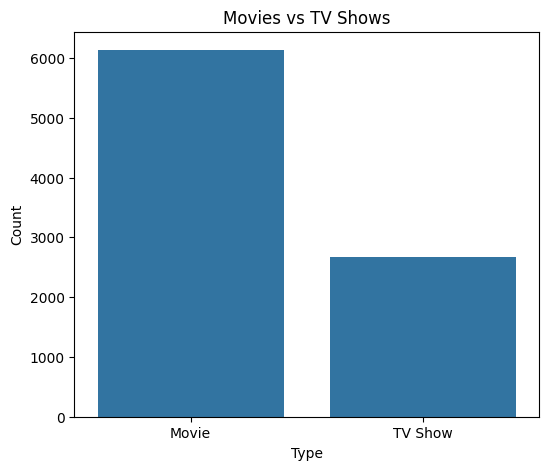

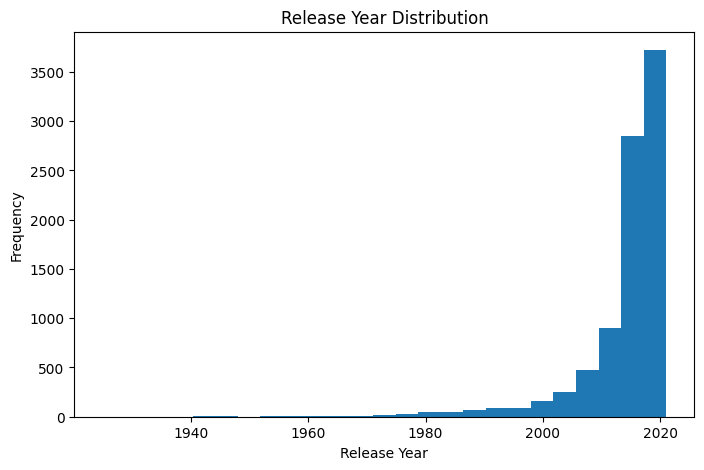

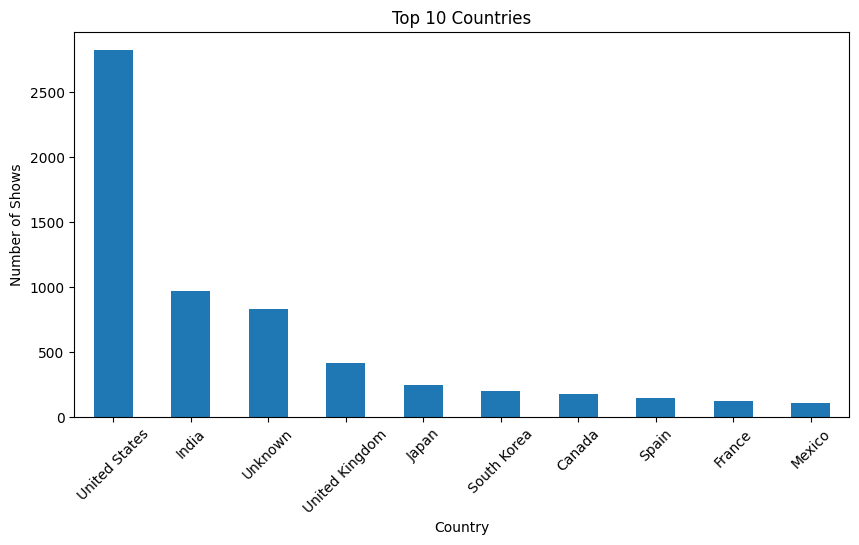

In [1]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. LOAD DATASET

df = pd.read_csv("netflix.csv")

print("=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)
print(df.head())

print("\nLAST 5 ROWS")
print(df.tail())

print("\nDataset Shape:")
print(df.shape)

# 3. CLEAN THE DATASET

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Remove Duplicate Rows
df.drop_duplicates(inplace=True)

# Fill Missing Values
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])
df["duration"] = df["duration"].fillna("Unknown")

# Convert date_added to datetime
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

print("\nData Cleaning Completed")

# 4. EXPLORE THE DATASET

print("\nDataset Information")
print("-" * 30)
df.info()

print("\nData Types")
print(df.dtypes)

print("\nColumn Names")
print(df.columns)

print("\nMovies and TV Shows")
print(df["type"].value_counts())

print("\nRatings")
print(df["rating"].value_counts())

print("\nTop 10 Countries")
print(df["country"].value_counts().head(10))

print("\nTop 10 Directors")
print(df["director"].value_counts().head(10))

print("\nTop 10 Genres")
print(df["listed_in"].value_counts().head(10))

print("\nMovies Released After 2020")
print(df[df["release_year"] > 2020][["title", "release_year"]].head())

print("\nGroup By Type")
print(df.groupby("type").size())

print("\nLatest Releases")
print(df.sort_values(by="release_year", ascending=False).head())

# 5. SUMMARIZE THE DATASET

print("\nNumerical Summary")
print(df.describe())

print("\nCategorical Summary")
print(df.describe(include="object"))

years = df["release_year"].to_numpy()

print("\nNumPy Summary")

print("Mean :", np.mean(years))
print("Median :", np.median(years))
print("Minimum :", np.min(years))
print("Maximum :", np.max(years))
print("Standard Deviation :", np.std(years))
print("Variance :", np.var(years))

# 6. EDA VISUALIZATIONS

# Count Plot
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="type")
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

# Histogram
plt.figure(figsize=(8,5))
plt.hist(df["release_year"], bins=25)
plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

#Bar Chart
plt.figure(figsize=(10,5))
df["country"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Shows")
plt.xticks(rotation=45)
plt.show()